# 02 · Training the Siamese U-Net

**Architecture.** One shared encoder runs over the reference-period statistics and
the inference-period statistics separately. At every scale the two feature maps
merge as `[pre, post, |pre − post|]` before the decoder — the absolute difference
is the learned analogue of the numerator of Eq. 3. The decoder emits one logit per
10 m pixel, which then passes through fixed 50/100/150 m smoothing averaged with
the raw layer (Section 2.2). Fixed, not learned: notebook 01 showed that smoothing
alone is worth ~9 AUC points, so there is no reason to make the decoder rediscover
it.

**Loss.** The paper's decision chain, made differentiable:

| paper | here |
|---|---|
| take the pixel raster | segmentation logits |
| smooth 50/100/150 m + raw, averaged | `smooth()`, fixed kernels |
| pool: mean of pixels inside a footprint | `pool()`, an `index_add_` segment mean |
| one score per building | pooled logit |
| threshold → damaged/undamaged | **not in the loss** — read off a PR curve afterwards |
| compare with UNOSAT's label | area-weighted BCE + soft-F1 |

The threshold stays out because it isn't differentiable, and the paper doesn't fix
it either — it picks the T maximising F1 per geography. Pooling happens on
**logits**: smoothing is linear there, matching what the PWTT does to T, whereas
pooling after a sigmoid would flatten a large building with one destroyed wing.

In [3]:
!pip install -q rasterio

In [4]:
import glob, os
import numpy as np, rasterio, torch, matplotlib.pyplot as plt
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_recall_curve, roc_auc_score

from google.colab import drive
drive.mount('/content/drive')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0); np.random.seed(0)
print(device)

Mounted at /content/drive
cuda


## Constants

Same as notebook 01. The 500 m core is the paper's aggregation unit; the 15 px
halo exists so the 150 m smoothing kernel reads real data rather than padding.

In [16]:
TILE_DIR = '/content/drive/MyDrive/s1_bda_labelled'            # labelled 29-band tiles from notebook 01
CKPT     = '/content/drive/MyDrive/siamese_unet.pt'   # survives a disconnect

PIX_M, CORE_PX, HALO_PX = 10, 50, 15
PATCH_PX = CORE_PX + 2 * HALO_PX            # 80 = 5 * 2^4
ORBITS, IN_CH = 2, 12

BAND_ORDER = (
    [f'{p}_o{o}_{b}' for p in ('pre','post') for o in range(ORBITS)
     for b in ('VV_mean','VV_sd','VH_mean','VH_sd','n','valid')]
    + ['fid', 'label', 'area', 'gx', 'gy'])
BI = {n: i for i, n in enumerate(BAND_ORDER)}

DB_OFFSET, DB_SCALE, SD_SCALE, N_SCALE = -12.0, 8.0, 3.0, 5.0

def normalize(x):
    """Per orbit: VV_mean, VV_sd, VH_mean, VH_sd, n, valid -> roughly [-1, 1]."""
    out = x.copy()
    for o in range(ORBITS):
        b = o * 6
        out[b+0] = (x[b+0] - DB_OFFSET) / DB_SCALE
        out[b+1] =  x[b+1] / SD_SCALE
        out[b+2] = (x[b+2] - DB_OFFSET) / DB_SCALE
        out[b+3] =  x[b+3] / SD_SCALE
        out[b+4] = np.log1p(np.maximum(x[b+4], 0)) / N_SCALE
    return np.nan_to_num(out, nan=0., posinf=0., neginf=0.)

## 1 · Split

Split by geography, never randomly by patch — neighbouring patches share buildings
and the same damage event, so a random split leaks and hides exactly the
generalisation failure the paper documents. With one city the best available
fallback is a north/south band, which is weak: Gaza City and Khan Younis are the
same conflict, sensor and month. Read the numbers as an upper bound.

With more cities, replace this with a list of tile paths per city.

In [18]:
tiles = sorted(p for p in glob.glob(f'{TILE_DIR}/*.tif') if not p.endswith('_s1.tif'))
top = {}
for t in tiles:
    with rasterio.open(t) as s:
        top[t] = s.bounds.top
cut = np.median(list(top.values()))
train_tiles = [t for t in tiles if top[t] >  cut]
val_tiles   = [t for t in tiles if top[t] <= cut]
print(f'{len(train_tiles)} train / {len(val_tiles)} val tiles')
print('val:', [os.path.basename(t) for t in val_tiles])

2 train / 2 val tiles
val: ['gaza_000.tif', 'gaza_002.tif']


## 2 · Dataset

One sample = one 500 m core plus its halo. Alongside the imagery each sample
carries a table of the footprints inside the core — local id, UNOSAT label, area.
That table is what turns a pixel raster into a building-level score.

In [19]:
class Patches(Dataset):
    def __init__(self, tiles, augment=False):
        self.tiles, self.augment, self.index = tiles, augment, []
        for fi, path in enumerate(tiles):
            with rasterio.open(path) as src:
                fid   = src.read(BI['fid'] + 1)
                valid = src.read(BI['pre_o0_valid'] + 1)
            h, w = fid.shape
            for r in range(0, h - CORE_PX + 1, CORE_PX):
                for c in range(0, w - CORE_PX + 1, CORE_PX):
                    if (fid[r:r+CORE_PX, c:c+CORE_PX].any()
                            and valid[r:r+CORE_PX, c:c+CORE_PX].mean() >= .5):
                        self.index.append((fi, r, c))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        fi, r0, c0 = self.index[i]
        with rasterio.open(self.tiles[fi]) as src:
            H, W = src.height, src.width
            r_lo, r_hi = r0 - HALO_PX, r0 + CORE_PX + HALO_PX
            c_lo, c_hi = c0 - HALO_PX, c0 + CORE_PX + HALO_PX
            win = rasterio.windows.Window(max(c_lo,0), max(r_lo,0),
                                          min(c_hi,W)-max(c_lo,0), min(r_hi,H)-max(r_lo,0))
            a = src.read(window=win).astype('float32')
        pad = ((0,0), (max(0,-r_lo), max(0, r_hi-H)), (max(0,-c_lo), max(0, c_hi-W)))
        if any(p for s in pad[1:] for p in s):
            a = np.pad(a, pad, mode='reflect')

        s = slice(HALO_PX, HALO_PX + CORE_PX)
        pre, post = normalize(a[:IN_CH]), normalize(a[IN_CH:2*IN_CH])
        raw_pre, raw_post = a[:IN_CH].copy(), a[IN_CH:2*IN_CH].copy()
        fid, lab, area = a[BI['fid']][s,s], a[BI['label']][s,s], a[BI['area']][s,s]

        if self.augment:
            k, flip = np.random.randint(4), np.random.rand() < .5
            aug = lambda x: (np.flip(np.rot90(x, k, (-2,-1)), -1) if flip
                             else np.rot90(x, k, (-2,-1))).copy()
            pre, post, raw_pre, raw_post = map(aug, (pre, post, raw_pre, raw_post))
            fid, lab, area = map(aug, (fid, lab, area))

        # footprints in this core -> local ids 1..K, background stays 0
        ids = np.unique(fid); ids = ids[ids != 0]
        seg = np.zeros_like(fid, dtype='int64')
        y = np.zeros(len(ids), 'float32'); w = np.zeros(len(ids), 'float32')
        for k_, f in enumerate(ids, 1):
            m = fid == f
            seg[m] = k_
            y[k_-1] = lab[m].max()
            w[k_-1] = max(area[m].max(), m.sum() * PIX_M**2)

        return dict(pre=torch.from_numpy(pre), post=torch.from_numpy(post),
                    raw_pre=torch.from_numpy(raw_pre), raw_post=torch.from_numpy(raw_post),
                    seg=torch.from_numpy(seg),
                    y=torch.from_numpy(y), w=torch.from_numpy(w))


def collate(batch):
    """Offset each sample's local segment ids so they stay unique across the batch."""
    segs, off = [], 0
    for b in batch:
        s = b['seg'].clone(); s[s > 0] += off; segs.append(s); off += b['y'].numel()
    out = {k: torch.stack([b[k] for b in batch])
           for k in ('pre','post','raw_pre','raw_post')}
    out['seg']   = torch.stack(segs)
    out['n_seg'] = off
    out['y']     = torch.cat([b['y'] for b in batch])
    out['w']     = torch.cat([b['w'] for b in batch])
    return out

In [15]:
import glob, os
print('TILE_DIR =', TILE_DIR)
print(sorted(os.path.basename(p) for p in glob.glob(f'{TILE_DIR}/*.tif')))
print('train', len(train_tiles), 'val', len(val_tiles))

TILE_DIR = /content/tiles
[]
train 0 val 0


In [20]:
train_ds, val_ds = Patches(train_tiles, augment=True), Patches(val_tiles)
print(f'{len(train_ds)} train patches / {len(val_ds)} val patches')

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate,
                      num_workers=2, drop_last=True)
val_dl   = DataLoader(val_ds, batch_size=16, collate_fn=collate, num_workers=2)

661 train patches / 788 val patches


## 3 · Smoothing, pooling, metrics

Three short functions, shared by the model, the loss and the baseline.

In [21]:
def disc(radius_px):
    y, x = torch.meshgrid(torch.arange(-radius_px, radius_px+1, dtype=torch.float32),
                          torch.arange(-radius_px, radius_px+1, dtype=torch.float32),
                          indexing='ij')
    k = ((x**2 + y**2) <= radius_px**2).float()
    return (k / k.sum())[None, None]

KERNELS = {r: disc(r).to(device) for r in (5, 10, 15)}      # 50, 100, 150 m

def smooth(x):
    """Section 2.2: mean of the raw layer and the three convolved ones."""
    layers = [x] + [F.conv2d(F.pad(x, (r,)*4, mode='reflect'), k)
                    for r, k in KERNELS.items()]
    return torch.stack(layers).mean(0)

def pool(logits, seg, n_seg):
    """Mean logit inside each footprint; segment 0 (background) is dropped."""
    v, s = logits.reshape(-1), seg.reshape(-1)
    sums = v.new_zeros(n_seg+1).index_add_(0, s, v)
    cnts = v.new_zeros(n_seg+1).index_add_(0, s, torch.ones_like(v))
    return sums[1:] / cnts[1:].clamp(min=1)

def metrics(score, y, w, threshold=None):
    score, y, w = np.asarray(score), np.asarray(y, float), np.asarray(w, float)
    if threshold is None:
        p, r, t = precision_recall_curve(y, score, sample_weight=w)
        threshold = t[int(np.nanargmax((2*p*r / np.maximum(p+r, 1e-9))[:-1]))]
    pred = (score > threshold).astype(float)
    tp = (w*pred*y).sum();     fp = (w*pred*(1-y)).sum()
    fn = (w*(1-pred)*y).sum(); tn = (w*(1-pred)*(1-y)).sum()
    P, R = tp/max(tp+fp,1e-9), tp/max(tp+fn,1e-9)
    return dict(AUC=100*roc_auc_score(y, score, sample_weight=w),
                Accuracy=100*(tp+tn)/(tp+tn+fp+fn),
                F1=100*2*P*R/max(P+R,1e-9), Precision=100*P, Recall=100*R,
                threshold=float(threshold))

## 4 · The number to beat

The analytic PWTT, scored through the identical pooling and metric code. If the
network only matches this, the paper's argument stands: an unsupervised statistic
needing no labels and running anywhere is the better tool.

In [22]:
def pwtt_T(pre, post):
    """Eq. 3-4 on the unnormalised dB stats: t per orbit and polarisation, T = max|t|."""
    ts = []
    for o in range(ORBITS):
        b = o*6
        n0, n1 = pre[:, b+4:b+5].clamp(min=2), post[:, b+4:b+5].clamp(min=2)
        valid  = pre[:, b+5:b+6] * post[:, b+5:b+6]
        for p in range(2):
            m0, s0 = pre[:, b+2*p:b+2*p+1],  pre[:, b+2*p+1:b+2*p+2]
            m1, s1 = post[:, b+2*p:b+2*p+1], post[:, b+2*p+1:b+2*p+2]
            ts.append(((m0-m1) / (s0**2/n0 + s1**2/n1).clamp(min=1e-6).sqrt()).abs() * valid)
    return torch.stack(ts).max(0).values

crop = lambda x: x[..., HALO_PX:HALO_PX+CORE_PX, HALO_PX:HALO_PX+CORE_PX]

@torch.no_grad()
def score(fn):
    S, Y, W = [], [], []
    for b in val_dl:
        S.append(pool(fn(b), b['seg'].to(device), b['n_seg']).cpu().numpy())
        Y.append(b['y'].numpy()); W.append(b['w'].numpy())
    return metrics(np.concatenate(S), np.concatenate(Y), np.concatenate(W))

baseline_fn = lambda b: crop(smooth(pwtt_T(b['raw_pre'].to(device), b['raw_post'].to(device))))
baseline = score(baseline_fn)
print('PWTT on the validation split:', {k: round(v,2) for k,v in baseline.items()})

PWTT on the validation split: {'AUC': np.float64(77.33), 'Accuracy': np.float64(69.88), 'F1': np.float64(63.22), 'Precision': np.float64(54.08), 'Recall': np.float64(76.06), 'threshold': 4.34}


## 5 · Model

In [23]:
def block(cin, cout):
    return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                         nn.BatchNorm2d(cout), nn.ReLU(True),
                         nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                         nn.BatchNorm2d(cout), nn.ReLU(True))

class SiameseUNet(nn.Module):
    def __init__(self, base=32, depth=4):
        super().__init__()
        self.depth = depth
        ch = [base * 2**i for i in range(depth + 1)]
        self.enc = nn.ModuleList([block(c, o) for c, o in zip([IN_CH] + ch[:-2], ch[:-1])])
        self.mid = block(ch[-2] * 3, ch[-1])
        self.up  = nn.ModuleList([nn.ConvTranspose2d(ch[i+1], ch[i], 2, 2)
                                  for i in reversed(range(depth))])
        self.dec = nn.ModuleList([block(ch[i] * 4, ch[i]) for i in reversed(range(depth))])
        self.head = nn.Conv2d(base, 1, 1)

    def encode(self, x):
        skips = []
        for b in self.enc:
            x = b(x); skips.append(x); x = F.max_pool2d(x, 2)
        return skips, x

    def forward(self, pre, post):
        sa, a = self.encode(pre)
        sb, b = self.encode(post)
        x = self.mid(torch.cat([a, b, (a-b).abs()], 1))
        for i, (up, dec) in enumerate(zip(self.up, self.dec)):
            l = self.depth - 1 - i
            x = dec(torch.cat([up(x), sa[l], sb[l], (sa[l]-sb[l]).abs()], 1))
        return crop(smooth(self.head(x)))

model = SiameseUNet().to(device)
print(f'{sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters')

11.7M parameters


## 6 · Loss

Area-weighted BCE on the pooled logit, plus a soft-F1 term aimed at the headline
metric. `pos_weight` comes from the training split so the same code survives the
move to a sparse city — Gaza is an unusually balanced ~57 % damaged, Sumy is
0.08 %.

In [24]:
pos = sum(float(b['y'].sum()) for b in train_dl)
neg = sum(float((1-b['y']).sum()) for b in train_dl)
pos_weight = torch.tensor(np.clip(neg/max(pos,1), 1, 50), dtype=torch.float32, device=device)
print(f'{100*pos/(pos+neg):.1f}% damaged  ->  pos_weight = {pos_weight.item():.2f}')

def criterion(logits, b, f1_weight=0.5):
    y = b['y'].to(device)
    s = pool(logits, b['seg'].to(device), b['n_seg'])
    w = b['w'].to(device).clamp(min=1)
    w = w / w.mean()                                  # area weights, mean 1
    loss = F.binary_cross_entropy_with_logits(s, y, weight=w, pos_weight=pos_weight)
    if f1_weight:
        p = torch.sigmoid(s)
        tp, fp, fn = (w*p*y).sum(), (w*p*(1-y)).sum(), (w*(1-p)*y).sum()
        loss = loss + f1_weight * (1 - (2*tp + 1e-6) / (2*tp + fp + fn + 1e-6))
    return loss

69.6% damaged  ->  pos_weight = 1.00


## 7 · Train

In [25]:
EPOCHS = 40
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
model_fn = lambda b: model(b['pre'].to(device), b['post'].to(device))

history, best = [], -1.0
for epoch in range(EPOCHS):
    model.train(); run = 0.0
    for b in train_dl:
        loss = criterion(model_fn(b), b)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        run += float(loss.detach())
    sched.step()

    model.eval()
    m = score(model_fn); m['loss'] = run / len(train_dl)
    history.append(m)
    print(f'{epoch:3d}  loss={m["loss"]:.4f}  AUC={m["AUC"]:6.2f}  F1={m["F1"]:6.2f}  '
          f'P={m["Precision"]:6.2f}  R={m["Recall"]:6.2f}   (PWTT {baseline["AUC"]:.2f})')

    if m['AUC'] > best:
        best = m['AUC']
        torch.save({'model': model.state_dict(), 'metrics': m, 'baseline': baseline}, CKPT)
print(f'\nbest {best:.2f}  |  PWTT {baseline["AUC"]:.2f}')

  0  loss=0.7152  AUC= 85.26  F1= 71.41  P= 74.76  R= 68.36   (PWTT 77.33)
  1  loss=0.6405  AUC= 81.41  F1= 67.13  P= 70.93  R= 63.72   (PWTT 77.33)
  2  loss=0.6239  AUC= 83.56  F1= 69.78  P= 72.08  R= 67.62   (PWTT 77.33)
  3  loss=0.6054  AUC= 81.34  F1= 66.76  P= 65.94  R= 67.60   (PWTT 77.33)
  4  loss=0.5963  AUC= 85.01  F1= 71.58  P= 73.94  R= 69.37   (PWTT 77.33)
  5  loss=0.5867  AUC= 73.02  F1= 56.98  P= 53.89  R= 60.43   (PWTT 77.33)
  6  loss=0.5903  AUC= 85.92  F1= 72.87  P= 73.97  R= 71.79   (PWTT 77.33)
  7  loss=0.5768  AUC= 84.35  F1= 69.67  P= 68.18  R= 71.23   (PWTT 77.33)
  8  loss=0.5756  AUC= 83.34  F1= 68.79  P= 65.62  R= 72.28   (PWTT 77.33)
  9  loss=0.5672  AUC= 79.97  F1= 64.70  P= 57.03  R= 74.74   (PWTT 77.33)
 10  loss=0.5685  AUC= 82.41  F1= 67.06  P= 63.07  R= 71.58   (PWTT 77.33)
 11  loss=0.5675  AUC= 83.42  F1= 67.96  P= 64.57  R= 71.72   (PWTT 77.33)
 12  loss=0.5683  AUC= 83.90  F1= 69.07  P= 66.24  R= 72.15   (PWTT 77.33)
 13  loss=0.5608  AUC= 81

KeyboardInterrupt: 

## 8 · Curves

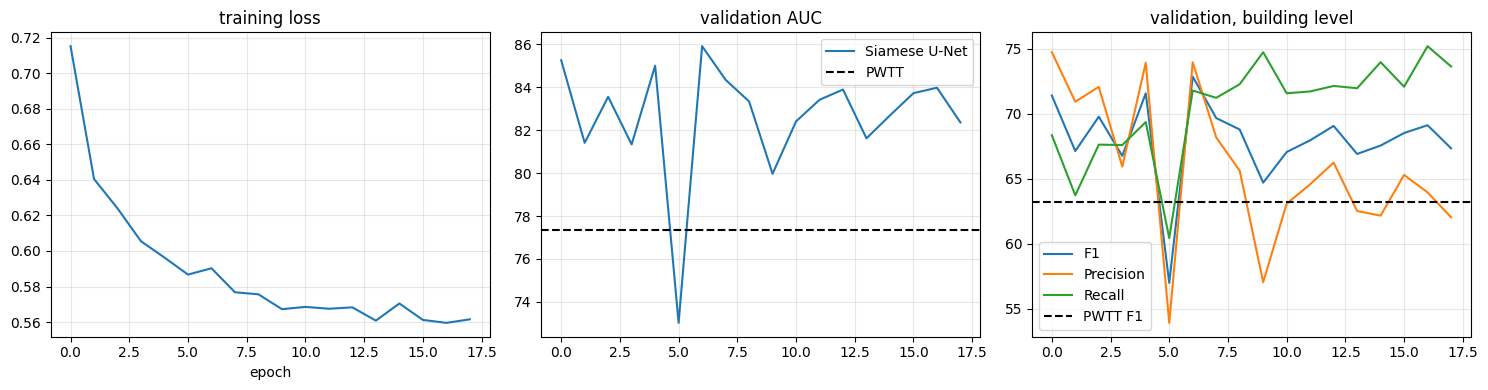

In [26]:
h = {k: [d[k] for d in history] for k in ('loss','AUC','F1','Precision','Recall')}
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(h['loss']); ax[0].set_title('training loss'); ax[0].set_xlabel('epoch')
ax[1].plot(h['AUC'], label='Siamese U-Net')
ax[1].axhline(baseline['AUC'], color='k', ls='--', label='PWTT')
ax[1].set_title('validation AUC'); ax[1].legend()
for k in ('F1','Precision','Recall'): ax[2].plot(h[k], label=k)
ax[2].axhline(baseline['F1'], color='k', ls='--', label='PWTT F1')
ax[2].set_title('validation, building level'); ax[2].legend()
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

Precision below recall is the expected signature and matches Section 3.3: false
positives cluster within ~30 m of real damage, so the model over-predicts the
*extent* of damaged blocks rather than inventing damage elsewhere. Notebook 03
tests that explicitly.

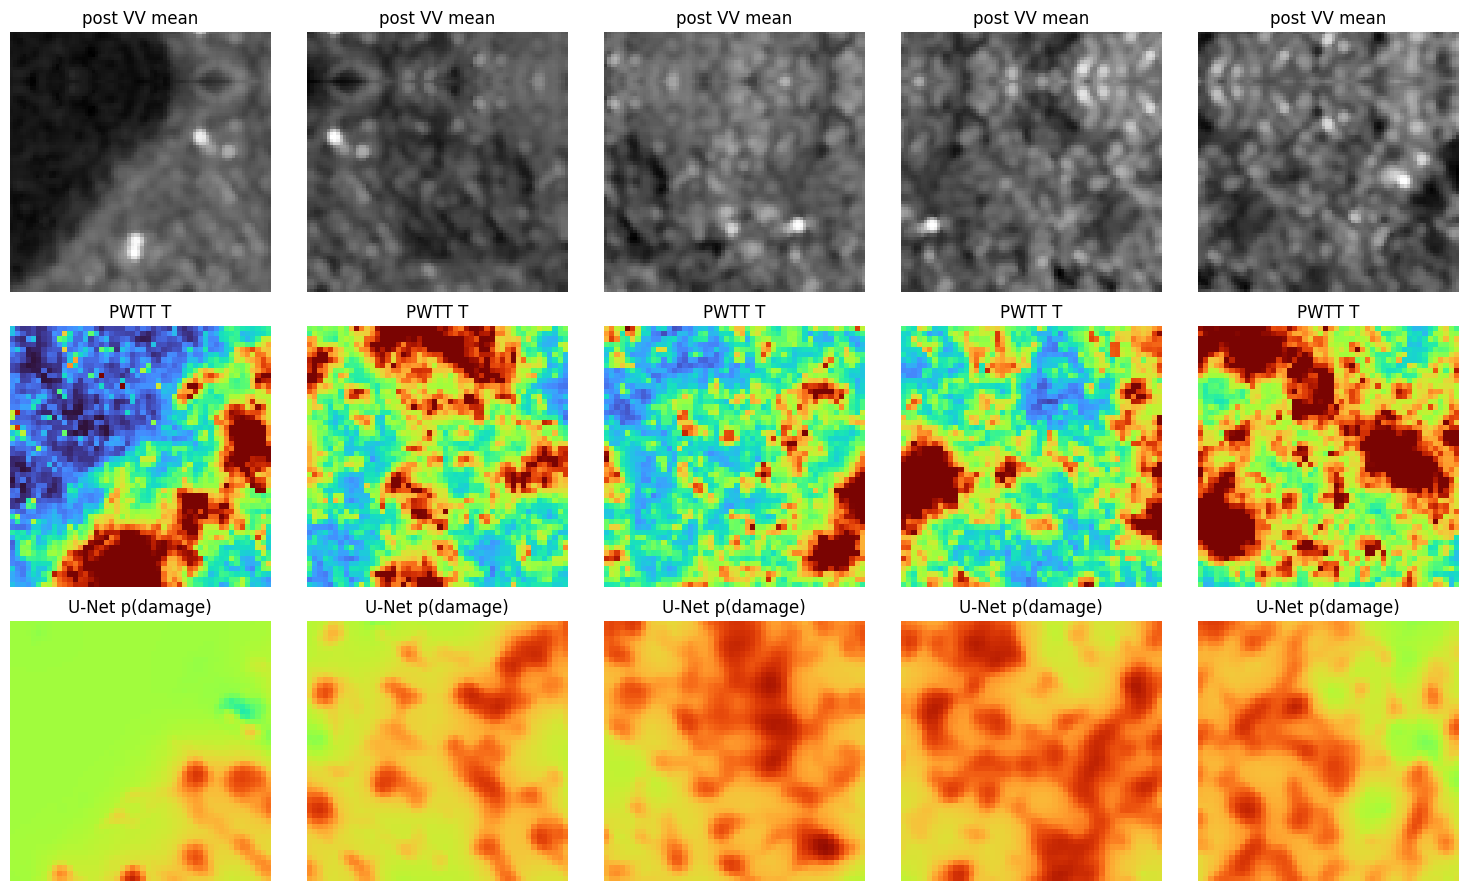

In [27]:
model.eval()
b = next(iter(val_dl))
with torch.no_grad():
    p = torch.sigmoid(model_fn(b)).cpu()
    T = crop(smooth(pwtt_T(b['raw_pre'].to(device), b['raw_post'].to(device)))).cpu()

fig, ax = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    ax[0,i].imshow(b['post'][i,0], cmap='gray');           ax[0,i].set_title('post VV mean')
    ax[1,i].imshow(T[i,0], vmin=2, vmax=6, cmap='turbo');  ax[1,i].set_title('PWTT T')
    ax[2,i].imshow(p[i,0], vmin=0, vmax=1, cmap='turbo');  ax[2,i].set_title('U-Net p(damage)')
    for r in range(3): ax[r,i].axis('off')
plt.tight_layout(); plt.show()

Checkpoint is on Drive, so a disconnect costs only the current epoch.

Notebook 03 runs whole-tile inference: during training a footprint straddling two
patch cores gets pooled twice over partial pixel sets, which is fine as a gradient
signal but not good enough for a reported number.